In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [2]:
df = pd.read_csv('customer_churn_nn.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:")
display(df.describe())
print(f"\nTarget Variable Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")

DATASET OVERVIEW
Number of rows: 2000
Number of columns: 17

Column Names:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled         

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



Target Variable Distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


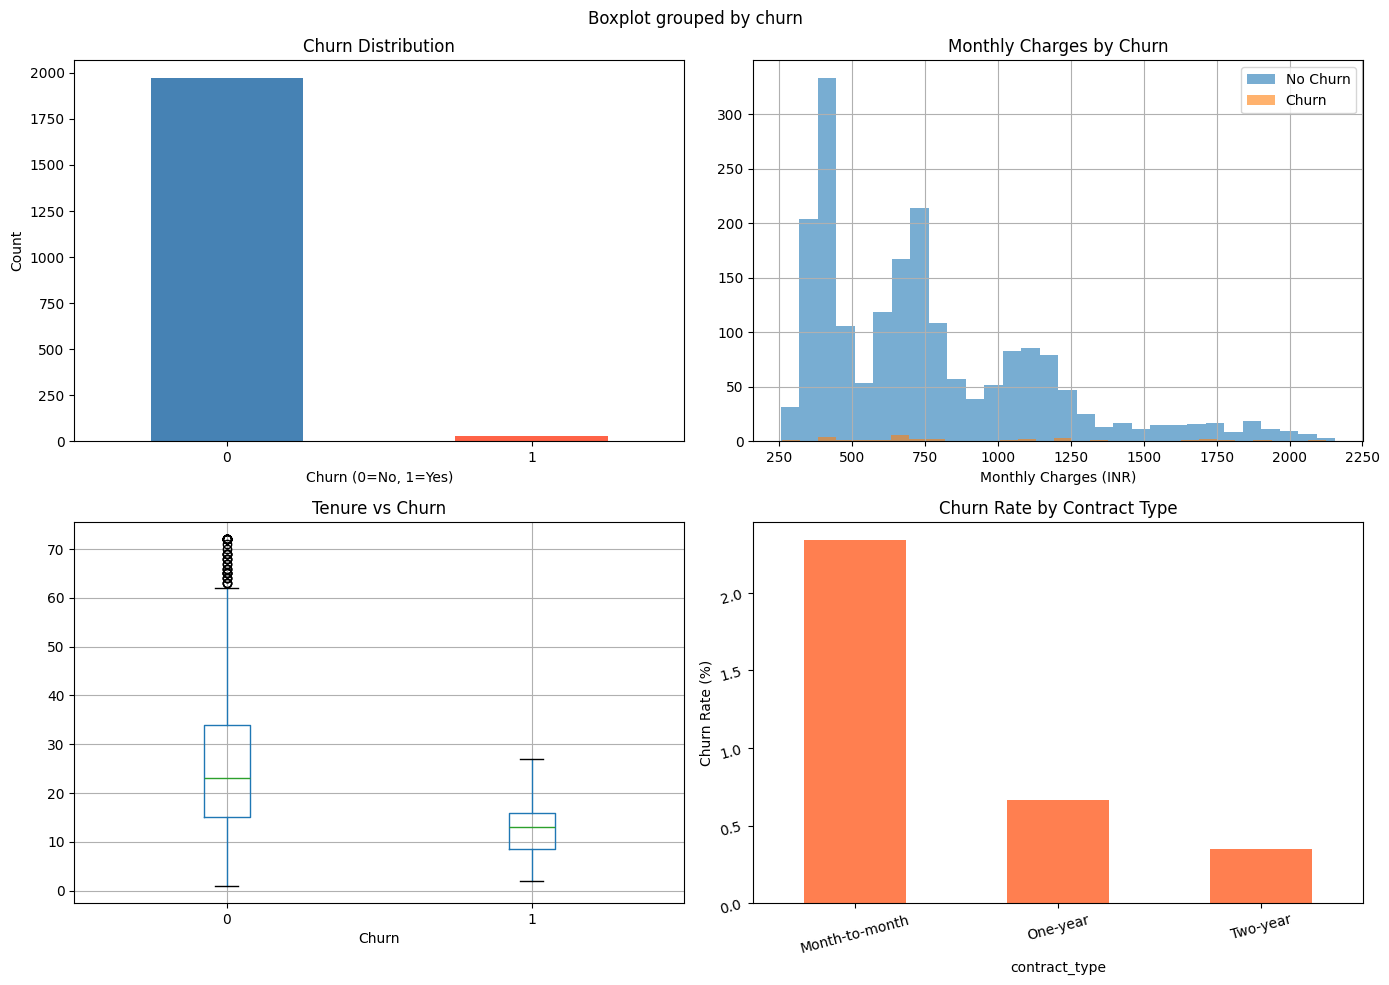

EDA plots saved!


In [3]:
#  EDA Visualizations
import os
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
df['churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

# Monthly charges distribution
df.groupby('churn')['monthly_charges_inr'].hist(alpha=0.6, ax=axes[0,1], bins=30)
axes[0,1].set_title('Monthly Charges by Churn')
axes[0,1].set_xlabel('Monthly Charges (INR)')
axes[0,1].legend(['No Churn', 'Churn'])

# Tenure vs Churn
df.boxplot(column='tenure_months', by='churn', ax=axes[1,0])
axes[1,0].set_title('Tenure vs Churn')
axes[1,0].set_xlabel('Churn')

# Contract type vs Churn
ct_churn = df.groupby('contract_type')['churn'].mean() * 100
ct_churn.plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Churn Rate by Contract Type')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(rotation=15)

plt.tight_layout()
plt.savefig('results/eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [4]:
# Data Preprocessing
df_processed = df.copy()

# Drop customer_id (identifier, not a feature)
df_processed.drop('customer_id', axis=1, inplace=True)

# Encode categorical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method', 'autopay_enabled']
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("Categorical columns encoded!")

# Separate features and target
X = df_processed.drop('churn', axis=1)
y = df_processed['churn']

print(f"\nFeature shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain size: {X_train_scaled.shape}")
print(f"Test size: {X_test_scaled.shape}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

Categorical columns encoded!

Feature shape: (2000, 15)
Target shape: (2000,)

Train size: (1600, 15)
Test size: (400, 15)
Train churn rate: 1.56%
Test churn rate: 1.50%


In [5]:
# Neural Network Model Building and Training
def build_model(hidden_layers=2, neurons=64, learning_rate=0.001, activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation='sigmoid'))  # Binary output

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build baseline model
model = build_model()
model.summary()

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("\nBaseline model training complete!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9398 - loss: 0.2744 - val_accuracy: 0.9937 - val_loss: 0.0709
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.0906 - val_accuracy: 0.9937 - val_loss: 0.0403
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9937 - val_loss: 0.0370
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9820 - loss: 0.0817 - val_accuracy: 0.9937 - val_loss: 0.0369
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9820 - loss: 0.0790 - val_accuracy: 0.9937 - val_loss: 0.0356
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0748 - val_accuracy: 0.9937 - val_loss: 0.0331
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9820 - loss: 0.0749 - val_accuracy: 0.9937 - val_loss: 0.0334
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9820 - loss: 0.0747 - val_accuracy: 0.9937 - val

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Test Accuracy: 98.75%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.99      1.00      0.99       394
       Churn       1.00      0.17      0.29         6

    accuracy                           0.99       400
   macro avg       0.99      0.58      0.64       400
weighted avg       0.99      0.99      0.98       400



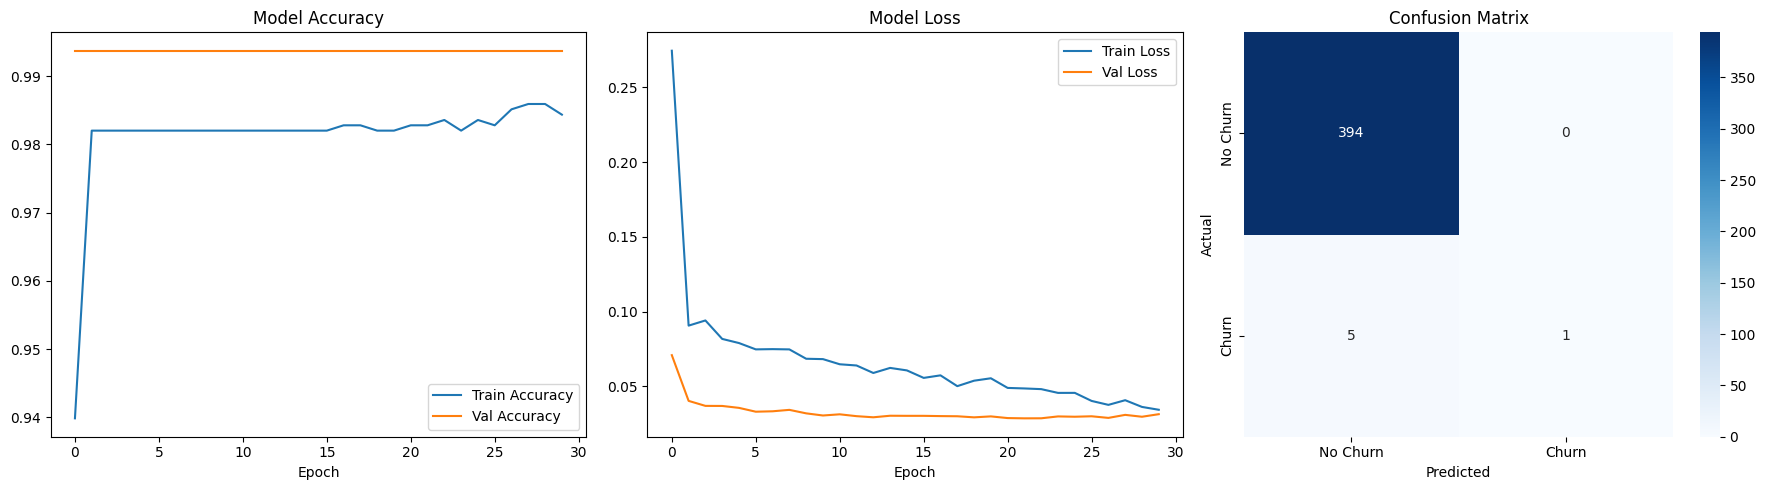

Evaluation plots saved!


In [6]:
# Model Evaluation
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Plot training curves + confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss curve
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=100, bbox_inches='tight')
plt.show()
print("Evaluation plots saved!")

In [7]:
# Hyperparameter Experimentation (3 experiments)
experiments = [
    {'name': 'Baseline',      'hidden_layers': 2, 'neurons': 64,  'lr': 0.001, 'batch': 32, 'epochs': 30, 'activation': 'relu'},
    {'name': 'More Neurons',  'hidden_layers': 2, 'neurons': 128, 'lr': 0.001, 'batch': 32, 'epochs': 30, 'activation': 'relu'},
    {'name': 'Deep Network',  'hidden_layers': 4, 'neurons': 64,  'lr': 0.001, 'batch': 32, 'epochs': 30, 'activation': 'relu'},
    {'name': 'Low LR',        'hidden_layers': 2, 'neurons': 64,  'lr': 0.0001,'batch': 32, 'epochs': 30, 'activation': 'relu'},
    {'name': 'Tanh Activation','hidden_layers': 2,'neurons': 64,  'lr': 0.001, 'batch': 32, 'epochs': 30, 'activation': 'tanh'},
]

results_list = []
for exp in experiments:
    print(f"\nRunning experiment: {exp['name']}...")
    m = build_model(exp['hidden_layers'], exp['neurons'], exp['lr'], exp['activation'])
    h = m.fit(X_train_scaled, y_train,
              epochs=exp['epochs'], batch_size=exp['batch'],
              validation_split=0.2, verbose=0)
    yp = (m.predict(X_test_scaled) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, yp)
    val_acc = max(h.history['val_accuracy'])
    results_list.append({
        'Experiment': exp['name'],
        'Hidden Layers': exp['hidden_layers'],
        'Neurons': exp['neurons'],
        'Learning Rate': exp['lr'],
        'Batch Size': exp['batch'],
        'Activation': exp['activation'],
        'Val Accuracy': round(val_acc, 4),
        'Test Accuracy': round(acc, 4)
    })
    print(f"  Test Accuracy: {acc*100:.2f}%")

results_df = pd.DataFrame(results_list)
print("\n" + "="*60)
print("HYPERPARAMETER COMPARISON TABLE")
print("="*60)
display(results_df)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print("Comparison table saved!")


Running experiment: Baseline...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
  Test Accuracy: 98.50%

Running experiment: More Neurons...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
  Test Accuracy: 98.25%

Running experiment: Deep Network...
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
  Test Accuracy: 98.25%

Running experiment: Low LR...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
  Test Accuracy: 98.50%

Running experiment: Tanh Activation...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
  Test Accuracy: 98.50%

HYPERPARAMETER COMPARISON TABLE


,Experiment,Hidden Layers,Neurons,Learning Rate,Batch Size,Activation,Val Accuracy,Test Accuracy
0,Baseline,2,64,0.0010,32,relu,0.9937,0.9850
1,More Neurons,2,128,0.0010,32,relu,0.9937,0.9825
2,Deep Network,4,64,0.0010,32,relu,0.9937,0.9825
3,Low LR,2,64,0.0001,32,relu,0.9937,0.9850
4,Tanh Activation,2,64,0.0010,32,tanh,0.9937,0.9850


Comparison table saved!


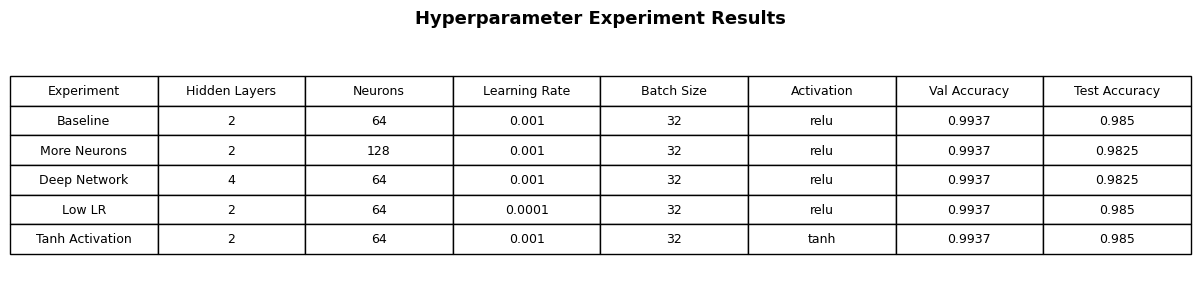

Comparison table image saved!


In [8]:
# Visualize comparison table
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
plt.title('Hyperparameter Experiment Results', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=120, bbox_inches='tight')
plt.show()
print("Comparison table image saved!")

In [12]:
# Download result files
from google.colab import files

files.download('results/evaluation_outputs.png')
files.download('results/model_comparison_table.png')
files.download('results/model_comparison_table.csv')
files.download('results/eda_plots.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>